# Notebook 1 — Datenexploration und kanonische Vorverarbeitung

**Ziel:** CloudAnoBench einlesen, die Feature-Schemata der drei Datensatztypen
(`mali`, `anom`, `norm`) systematisch analysieren, ein kanonisches Feature-Set ableiten
und bereinigte Artefakte für die nachfolgenden Modellierungsschritte bereitstellen.

**Schwerpunkte:**
- Zählung von Cases, Szenarien und Metrik-Zeilen
- Datenqualitätsprüfung und Quote-Stripping
- Analyse strukturell fehlender Features
- Ableitung des kanonischen Feature-Sets und der 5 universellen Features
- Vorbereitung der metrischen Baseline in Notebook 2

In [1]:
import pandas as pd
import os


base_path = os.path.join(os.getcwd(), "..", "data")

def load_all_data(base_path, dataset_type, label):
    """
    Lädt alle CSV-Cases eines Dataset-Typs rekursiv aus der Ordnerstruktur.
    quoting=3 (QUOTE_NONE) behandelt Anführungszeichen-enkodierte Dateien korrekt.
    Gibt DataFrame mit Metadaten (scenario_id, dataset_type, case_id, label) zurück.
    """
    all_dfs = []
    total_rows = 0
    clean_rows = 0
    file_stats = []
    
    dataset_path = os.path.join(base_path, f"{dataset_type}_dataset")
    
    for scenario in sorted(os.listdir(dataset_path)):
        scenario_path = os.path.join(dataset_path, scenario)
        
        if os.path.isdir(scenario_path):
            
            for file in sorted(os.listdir(scenario_path)):
                if file.endswith(".csv"):
                    
                    file_path = os.path.join(scenario_path, file)
                    
                    # Roh laden zum Zählen
                    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                        raw_lines = sum(1 for _ in f)  - 1  # Header abziehen
                    
                    # Sauber laden
                    df = pd.read_csv(file_path, on_bad_lines="skip", quoting=3)
                    #quoting=3 ignoriert Zeilen mit Anführungszeichen-Parsing-Fehlern
                    
                    # Anführungszeichen aus Spaltennamen entfernen
                    df.columns = df.columns.str.strip('"')
                    
                    total_rows += raw_lines
                    clean_rows += len(df)
                    
                    file_stats.append({
                        "file": file,
                        "scenario": scenario,
                        "raw_lines": raw_lines,
                        "clean_rows": len(df),
                        "dropped": raw_lines - len(df)
                    })
                    
                    # Metadaten
                    df["scenario_id"] = scenario
                    df["dataset_type"] = dataset_type
                    df["case_id"] = file
                    df["label"] = label
                    
                    all_dfs.append(df)
    
    stats_df = pd.DataFrame(file_stats)
    
    print("Total raw rows:", total_rows)
    print("Total clean rows:", clean_rows)
    print("Dropped rows:", total_rows - clean_rows)
    
    return pd.concat(all_dfs, ignore_index=True), stats_df

In [2]:
# Labels:
# mali = 1 (Zielklasse: malicious — Sicherheitsangriffe)
# anom = 0 und norm = 0 (negative Klassen)
# anom umfasst technische Anomalien (z. B. Hardware-Fehler), aber keine Sicherheitsangriffe.
# norm umfasst planmäßigen Betrieb, darunter ressourcenintensive, aber benigne Prozesse.
# Die spätere Klassifikation lautet daher: mali vs. (anom + norm).
mali, mali_stats = load_all_data(base_path, "mali", 1)
anom, anom_stats = load_all_data(base_path, "anom", 0)
norm, norm_stats = load_all_data(base_path, "norm", 0)

# Drop-Analyse für alle drei
for name, stats in [("mali", mali_stats), ("anom", anom_stats), ("norm", norm_stats)]:
    stats["drop_ratio"] = stats["dropped"] / stats["raw_lines"]
    print(f"\n{name} - Gesamt Drop Rate: {stats['dropped'].sum() / stats['raw_lines'].sum():.2%}")
    print(stats.sort_values("drop_ratio", ascending=False).head())

Total raw rows: 19385
Total clean rows: 19384
Dropped rows: 1


Total raw rows: 41400
Total clean rows: 41400
Dropped rows: 0


Total raw rows: 51208
Total clean rows: 51208
Dropped rows: 0



mali - Gesamt Drop Rate: 0.01%
             file    scenario  raw_lines  clean_rows  dropped  drop_ratio
13  mali_1_21.csv  scenario_1         82          81        1    0.012195
1   mali_1_10.csv  scenario_1         90          90        0    0.000000
0    mali_1_1.csv  scenario_1         90          90        0    0.000000
3   mali_1_12.csv  scenario_1         92          92        0    0.000000
4   mali_1_13.csv  scenario_1         88          88        0    0.000000

anom - Gesamt Drop Rate: 0.00%
              file    scenario  raw_lines  clean_rows  dropped  drop_ratio
459   anom_9_9.csv  scenario_9         90          90        0         0.0
0     anom_1_1.csv  scenario_1         90          90        0         0.0
1    anom_1_10.csv  scenario_1         90          90        0         0.0
2    anom_1_11.csv  scenario_1         90          90        0         0.0
3    anom_1_12.csv  scenario_1         90          90        0         0.0

norm - Gesamt Drop Rate: 0.00%
          

In [3]:
print(mali.shape, anom.shape, norm.shape)
print(mali.columns.tolist())

(19384, 11) (41400, 16) (51208, 33)
['timestamp', 'cpu_usage', 'mem_usage', 'disk_io', 'net_in', 'net_out', 'scenario_id', 'dataset_type', 'case_id', 'label', 'gpu_usage']


In [4]:
# Welche Spalten haben anom und norm extra?
print("anom extra:", set(anom.columns) - set(mali.columns))
print("norm extra:", set(norm.columns) - set(mali.columns))

# Untersuchung der _17-Dateien (ursprünglicher Verdacht auf kaputten Header)
mali_stats[mali_stats["file"].str.contains("17")]
# Ergebnis: In den _17-Dateien wurde kein kaputter Header festgestellt.
# Alle _17-Dateien weisen 0 verworfene Zeilen auf.
# Der einzige verworfene Datensatz stammt aus mali_1_21.csv (siehe Cell oben) und ist davon unabhängig.

anom extra: {'disk_usage_percent', 'cpu_steal_time', 'total_cpu_time', 'steal_time', 'cpu_steal'}
norm extra: {'app_cpu_usage', 'connections', 'db_cpu', 'db_net_in', 'db_cpu_usage', 'app_cpu', 'db_net_out', 'db_mem_usage', 'cache_hits', 'app_latency', 'app_latency_ms', 'memory_usage', 'tcp_connections', 'db_disk_io', 'response_time_ms', 'network_connections', 'app_mem', 'network_traffic', 'app_mem_usage', 'concurrent_connections', 'cache_misses', 'net_connections', 'latency_ms'}


,file,scenario,raw_lines,clean_rows,dropped,drop_ratio
8,mali_1_17.csv,scenario_1,89,89,0,0.0
63,mali_2_17.csv,scenario_2,71,71,0,0.0
87,mali_3_17.csv,scenario_3,43,43,0,0.0
111,mali_4_17.csv,scenario_4,90,90,0,0.0
135,mali_5_17.csv,scenario_5,90,90,0,0.0
159,mali_6_17.csv,scenario_6,90,90,0,0.0
183,mali_7_17.csv,scenario_7,90,90,0,0.0
214,mali_9_17.csv,scenario_9,90,90,0,0.0


In [5]:
meta_cols = {'scenario_id', 'dataset_type', 'case_id', 'label', 'timestamp'}

mali_features = set(mali.columns) - meta_cols
anom_features = set(anom.columns) - meta_cols
norm_features = set(norm.columns) - meta_cols

canonical = mali_features | anom_features | norm_features

print(f"Kanonisches Feature-Set: {len(canonical)} Features")
print(sorted(canonical))

# Welche Features fehlen in welchem Dataset?
print(f"\nNur in mali:  {mali_features - anom_features - norm_features}")
print(f"Nur in anom:  {anom_features - mali_features - norm_features}")
print(f"Nur in norm:  {norm_features - mali_features - anom_features}")
print(f"In allen 3:   {mali_features & anom_features & norm_features}")

Kanonisches Feature-Set: 34 Features
['app_cpu', 'app_cpu_usage', 'app_latency', 'app_latency_ms', 'app_mem', 'app_mem_usage', 'cache_hits', 'cache_misses', 'concurrent_connections', 'connections', 'cpu_steal', 'cpu_steal_time', 'cpu_usage', 'db_cpu', 'db_cpu_usage', 'db_disk_io', 'db_mem_usage', 'db_net_in', 'db_net_out', 'disk_io', 'disk_usage_percent', 'gpu_usage', 'latency_ms', 'mem_usage', 'memory_usage', 'net_connections', 'net_in', 'net_out', 'network_connections', 'network_traffic', 'response_time_ms', 'steal_time', 'tcp_connections', 'total_cpu_time']

Nur in mali:  set()
Nur in anom:  {'disk_usage_percent', 'cpu_steal_time', 'total_cpu_time', 'steal_time', 'cpu_steal'}
Nur in norm:  {'app_cpu_usage', 'connections', 'db_cpu', 'db_net_in', 'db_cpu_usage', 'app_cpu', 'db_net_out', 'db_mem_usage', 'cache_hits', 'app_latency', 'app_latency_ms', 'memory_usage', 'tcp_connections', 'db_disk_io', 'response_time_ms', 'network_connections', 'app_mem', 'network_traffic', 'app_mem_usage',

Das kanonische Feature-Set umfasst 34 Features. Da nur 5 Features in allen drei Datensatztypen vorhanden sind, bleiben schema-bedingt fehlende Werte als NaN erhalten. Die leakage-freie Medianimputation erfolgt in Notebook 2 ausschließlich auf Basis der Trainingszeilen.

In [6]:
# Gibt es irgendwo eine text/log Spalte?
for col in mali.columns:
    if mali[col].dtype == object and col != 'timestamp':
        print(col, mali[col].iloc[0])

cpu_usage 21.38
net_out 1.66
scenario_id scenario_1
dataset_type mali
case_id mali_1_1.csv


In [7]:
import pandas as pd

datasets = {"mali": mali, "anom": anom, "norm": norm}
check_cols = sorted(canonical)

for name, df in datasets.items():
    print(f"\nDataset: {name}")
    # Schleife 1: Prüft auf nicht-numerische Zeichen (Komma, %, Buchstaben) — 
    # Hinweis auf residuale Anführungszeichen oder falsche Datentypen
    for col in check_cols:
        if col not in df.columns:
            continue
        s_orig = df[col]
        s = s_orig.astype(str)
        comma_cnt = s.str.contains(",", na=False).sum()
        pct_cnt = s.str.contains("%", na=False).sum()
        alpha_cnt = s.str.contains(r"[A-Za-z]", na=False).sum()
        if comma_cnt + pct_cnt + alpha_cnt > 0:
            examples = s[s.str.contains(r"[,%A-Za-z]", na=False)].unique()[:6]
            print(f"  {col}: comma={comma_cnt}, %={pct_cnt}, alpha={alpha_cnt}, examples={examples}")

    # zusätzliche Konvertierbarkeitstest (Komma->Punkt)
    bad_cols = []
    # Schleife 2: Prüft ob Werte nach Komma→Punkt-Ersatz konvertierbar sind —
    # fängt europäische Dezimaltrennzeichen ab
    for col in check_cols:
        if col not in df.columns:
            continue
        coerced = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")
        nonconvert_idx = coerced.isna() & df[col].notna()
        if nonconvert_idx.any():
            sample = df.loc[nonconvert_idx, col].astype(str).unique()[:5]
            bad_cols.append((col, nonconvert_idx.sum(), sample))
    if bad_cols:
        print("  Nicht-konvertierbare Werte (nach Komma->Punkt):")
        for col, cnt, sample in bad_cols:
            print(f"    {col}: {cnt} non-convert, Beispiele: {sample}")
    else:
        print("  Alle kanonischen Spalten konvertieren sich (nach Komma->Punkt).")


Dataset: mali
  cpu_usage: comma=0, %=0, alpha=9, examples=['nan']
  disk_io: comma=0, %=0, alpha=10, examples=['nan']


  gpu_usage: comma=0, %=0, alpha=19303, examples=['nan']
  mem_usage: comma=0, %=0, alpha=9, examples=['nan']
  net_in: comma=0, %=0, alpha=281, examples=['nan' '3.838051890847627e-06']
  net_out: comma=0, %=0, alpha=100, examples=['nan']


  Nicht-konvertierbare Werte (nach Komma->Punkt):
    cpu_usage: 2 non-convert, Beispiele: ['"99.73' '"99.91']
    net_out: 1132 non-convert, Beispiele: ['1.58"' '1.72"' '1.49"' '1.66"' '1.55"']

Dataset: anom
  cpu_steal: comma=0, %=0, alpha=40320, examples=['nan']


  cpu_steal_time: comma=0, %=0, alpha=40230, examples=['nan']
  disk_io: comma=0, %=0, alpha=1, examples=['5.472489930791192e-06']


  disk_usage_percent: comma=0, %=0, alpha=41310, examples=['nan']
  gpu_usage: comma=0, %=0, alpha=41310, examples=['nan']


...

  memory_usage: comma=0, %=0, alpha=51118, examples=['nan']
  net_connections: comma=0, %=0, alpha=51028, examples=['nan']


  net_in: comma=0, %=0, alpha=990, examples=['nan']
  net_out: comma=0, %=0, alpha=1170, examples=['nan']


  network_connections: comma=0, %=0, alpha=50488, examples=['nan']
  network_traffic: comma=0, %=0, alpha=51118, examples=['nan']


  response_time_ms: comma=0, %=0, alpha=51118, examples=['nan']
  tcp_connections: comma=0, %=0, alpha=51118, examples=['nan']


  Alle kanonischen Spalten konvertieren sich (nach Komma->Punkt).


In [8]:
import numpy as np

def build_canonical_matrix(df, canonical_features, fit_medians=None):
    """
    Schemaharmonisierung und numerische Konvertierung für das kanonische Feature-Set.

    - Fehlende Spalten werden als NaN ergänzt (schema-bedingte Lücken).
    - String-Werte (residuale Anführungszeichen aus quoting=3) werden zu float konvertiert.
    - Keine Medianimputation: fehlende Werte verbleiben als NaN in den Parquet-Dateien.
      Leakage-freie Imputation erfolgt in Notebook 2 ausschließlich auf Basis der
      Trainingszeilen aller drei dataset_types (globaler Median).

    fit_medians: nicht mehr verwendet — veraltet, nur noch für API-Kompatibilität.
    """
    df = df.copy()

    for col in canonical_features:
        if col not in df.columns:
            df[col] = np.nan

    cols = (['timestamp'] if 'timestamp' in df.columns else []) + \
           sorted(canonical_features) + \
           ['scenario_id', 'dataset_type', 'case_id', 'label']
    df = df[[c for c in cols if c in df.columns]].copy()

    for col in sorted(canonical_features):
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.strip().str.strip('"\'')
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Keine Imputation — NaN verbleiben für leakage-freie Behandlung in Notebook 2
    return df, {}


mali_clean, _ = build_canonical_matrix(mali.copy(), canonical)
anom_clean, _ = build_canonical_matrix(anom.copy(), canonical)
norm_clean, _ = build_canonical_matrix(norm.copy(), canonical)

print(mali_clean.shape, anom_clean.shape, norm_clean.shape)
print("NaN remaining mali:", mali_clean.isnull().sum().sum())
print("NaN remaining anom:", anom_clean.isnull().sum().sum())
print("NaN remaining norm:", norm_clean.isnull().sum().sum())

# NaN-Spalten dokumentieren (schema-bedingt oder Konvertierungsfehler)
for name, df in [("mali", mali_clean), ("anom", anom_clean), ("norm", norm_clean)]:
    nan_cols = [c for c in sorted(canonical) if df[c].isnull().any()]
    print(f"{name}: {len(nan_cols)} NaN-Spalten (schema-bedingt + ggf. Konvertierungsfehler): {nan_cols}")


(19384, 39) (41400, 39) (51208, 39)
NaN remaining mali: 562462
NaN remaining anom: 1197900
NaN remaining norm: 1479992
mali: 34 NaN-Spalten (schema-bedingt + ggf. Konvertierungsfehler): ['app_cpu', 'app_cpu_usage', 'app_latency', 'app_latency_ms', 'app_mem', 'app_mem_usage', 'cache_hits', 'cache_misses', 'concurrent_connections', 'connections', 'cpu_steal', 'cpu_steal_time', 'cpu_usage', 'db_cpu', 'db_cpu_usage', 'db_disk_io', 'db_mem_usage', 'db_net_in', 'db_net_out', 'disk_io', 'disk_usage_percent', 'gpu_usage', 'latency_ms', 'mem_usage', 'memory_usage', 'net_connections', 'net_in', 'net_out', 'network_connections', 'network_traffic', 'response_time_ms', 'steal_time', 'tcp_connections', 'total_cpu_time']
anom: 29 NaN-Spalten (schema-bedingt + ggf. Konvertierungsfehler): ['app_cpu', 'app_cpu_usage', 'app_latency', 'app_latency_ms', 'app_mem', 'app_mem_usage', 'cache_hits', 'cache_misses', 'concurrent_connections', 'connections', 'cpu_steal', 'cpu_steal_time', 'db_cpu', 'db_cpu_usage',

In [9]:
total_pos = len(mali_clean)
total_neg = len(anom_clean) + len(norm_clean)
ratio = total_neg / total_pos

print(f"Klassen-Verteilung:")
print(f"  mali  (label=1): {total_pos:>7,}")
print(f"  anom  (label=0): {len(anom_clean):>7,}")
print(f"  norm  (label=0): {len(norm_clean):>7,}")
print(f"  Ratio negativ:positiv = {ratio:.1f}:1")
print(f"  -> scale_pos_weight (explorativ, Gesamtdatensatz): {ratio:.2f}")

# Hinweis: Dieser Wert basiert auf dem Gesamtdatensatz und dient hier nur der explorativen Übersicht.
# Das Klassenverhältnis und der tatsächlich verwendete scale_pos_weight werden im
# Modellierungsnotebook (Notebook 02) ausschließlich aus dem Trainingssplit bestimmt.


Klassen-Verteilung:
  mali  (label=1):  19,384
  anom  (label=0):  41,400
  norm  (label=0):  51,208
  Ratio negativ:positiv = 4.8:1
  -> scale_pos_weight (explorativ, Gesamtdatensatz): 4.78


In [10]:
import os

processed_path = os.path.join(base_path, "processed")
os.makedirs(processed_path, exist_ok=True)

# Timestamp einheitlich als string konvertieren
for df in [mali_clean, anom_clean, norm_clean]:
    df['timestamp'] = df['timestamp'].astype(str)

mali_clean.to_parquet(os.path.join(processed_path, "mali_clean.parquet"), index=False)
anom_clean.to_parquet(os.path.join(processed_path, "anom_clean.parquet"), index=False)
norm_clean.to_parquet(os.path.join(processed_path, "norm_clean.parquet"), index=False)

# Hinweis: Keine Medianimputation in diesem Notebook.
# Leakage-freie Imputation mit globalen Train-Medianen erfolgt in Notebook 2.
# Das Artefakt train_medians.json wird dort unter data/processed/ gespeichert.
print("Gespeichert in data/processed/:", os.listdir(processed_path))


Gespeichert in data/processed/: ['anom_clean.parquet', 'mali_clean.parquet', 'mali_train_medians.json', 'norm_clean.parquet', 'train_medians.json']


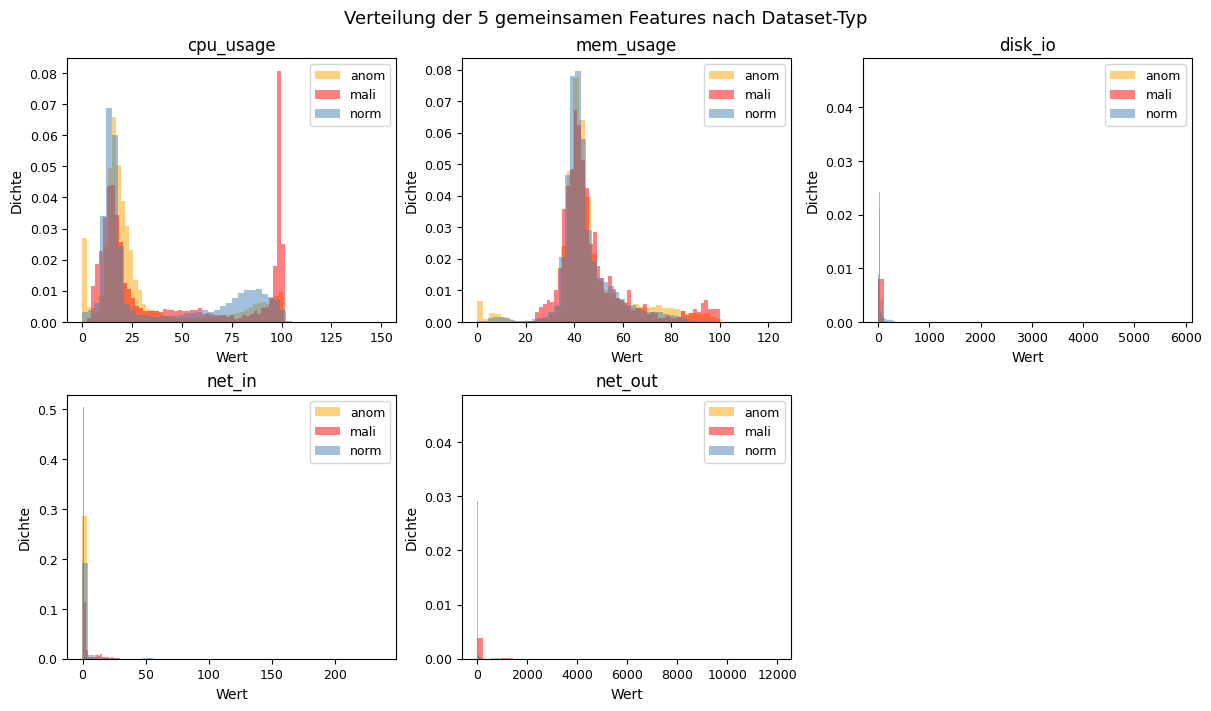

Plot gespeichert.


In [11]:
import matplotlib.pyplot as plt

# Nur die 5 universellen Features — einzige die in allen 3 Datasets vorhanden sind
# Verteilungsunterschiede motivieren den Bedarf an Log-Kontext (vgl. Phase 3)
common = ['cpu_usage', 'mem_usage', 'disk_io', 'net_in', 'net_out']
combined = pd.concat([
    mali_clean.assign(typ='mali'),
    anom_clean.assign(typ='anom'),
    norm_clean.assign(typ='norm')
])

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
ax_flat = axes.flat
colors = {'mali': 'red', 'anom': 'orange', 'norm': 'steelblue'}

for ax, col in zip(ax_flat, common):
    for typ, grp in combined.groupby('typ'):
        ax.hist(grp[col].dropna(), bins=50, alpha=0.5,
                label=typ, density=True, color=colors[typ])
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Wert", fontsize=10)
    ax.set_ylabel("Dichte", fontsize=10)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=9)

ax_flat[5].set_visible(False)

plt.suptitle("Verteilung der 5 gemeinsamen Features nach Dataset-Typ", fontsize=13)

os.makedirs("../docs", exist_ok=True)
plt.savefig("../docs/feature_distributions.png", dpi=200, bbox_inches='tight')
plt.show()
print("Plot gespeichert.")

In [12]:
# Roundtrip-Verifikation: stellt sicher dass Parquet Datentypen verlustfrei erhält
# und spätere Notebooks exakt dieselben Shapes laden (Qualitätssicherung)
for name, df in [("mali", mali_clean), ("anom", anom_clean), ("norm", norm_clean)]:
    _test = pd.read_parquet(os.path.join(processed_path, f"{name}_clean.parquet"))
    assert _test.shape == df.shape, f"Roundtrip fehlgeschlagen für {name}!"
    print(f"Roundtrip OK {name}:", _test.shape)

Roundtrip OK mali: (19384, 39)
Roundtrip OK anom: (41400, 39)
Roundtrip OK norm: (51208, 39)


In [13]:
# Log-Dateien: Existenz, Struktur und Verknüpfungsschlüssel für Phase 3
log_files = []
for dataset_type in ['mali', 'anom', 'norm']:
    dataset_path = os.path.join(base_path, f"{dataset_type}_dataset")
    for scenario in sorted(os.listdir(dataset_path)):
        scenario_path = os.path.join(dataset_path, scenario)
        if os.path.isdir(scenario_path):
            for file in os.listdir(scenario_path):
                if file.endswith(".log"):
                    log_files.append({
                        "dataset_type": dataset_type,
                        "scenario": scenario,
                        "file": file
                    })

log_df = pd.DataFrame(log_files)
if len(log_df) > 0:
    print(f"Log-Dateien gesamt: {len(log_df)}")
    print(log_df.groupby('dataset_type')['file'].count())
    print("\nBeispiel-Einträge:")
    print(log_df.head(6).to_string(index=False))
    
    # Erste Log-Datei lesen und Struktur zeigen
    sample = log_df.iloc[0]
    sample_path = os.path.join(base_path, f"{sample['dataset_type']}_dataset",
                               sample['scenario'], sample['file'])
    with open(sample_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = [f.readline() for _ in range(5)]
    print(f"\nBeispiel-Log ({sample['file']}):")
    for l in lines:
        print(" ", l.rstrip())
else:
    print("Keine .log-Dateien gefunden — Log-Daten liegen ggf. in anderem Format vor")
    print("Verknüpfungsschlüssel für Phase 3: scenario_id + case_id")

Log-Dateien gesamt: 1252
dataset_type
anom    460
mali    223
norm    569
Name: file, dtype: int64

Beispiel-Einträge:
dataset_type   scenario          file
        mali scenario_1  mali_1_1.log
        mali scenario_1 mali_1_10.log
        mali scenario_1 mali_1_11.log
        mali scenario_1 mali_1_12.log
        mali scenario_1 mali_1_13.log
        mali scenario_1 mali_1_14.log

Beispiel-Log (mali_1_1.log):
  Aug 15 10:00:05 systemd[1]: Started Session 5 of user admin.
  Aug 15 10:00:15 sshd[11532]: Accepted publickey for admin from 10.0.2.5 port 54321 ssh2
  Aug 15 10:00:40 cron[11590]: (root) CMD (   /usr/lib/apt/apt.systemd.daily)
  Aug 15 10:01:15 kubelet[1234]: INFO Successfully probed container metrics-server
  Aug 15 10:01:40 nginx[5432]: GET /healthz HTTP/1.1 200 OK


## Zusammenfassung und Übergabe an Notebook 2

- **34 kanonische Features** wurden identifiziert (Union aller Feature-Spalten über mali, anom, norm).
- Davon sind **5 universelle Features** in allen drei Datensatztypen vorhanden:
  `cpu_usage`, `mem_usage`, `disk_io`, `net_in`, `net_out`.
- Die Analyse zeigt ein **Schema-Leakage-Risiko**:
  Mehrere Features fehlen strukturell nur in bestimmten Datensatztypen
  (28 NaN-Spalten in mali, 23 in anom, 6 in norm) und könnten dadurch
  die Klassenzugehörigkeit indirekt kodieren. Deshalb werden in der Modellierung
  ausschließlich die 5 universellen Features verwendet.
- Bereinigte Parquet-Artefakte (`mali_clean.parquet`, `anom_clean.parquet`,
  `norm_clean.parquet`) wurden unter `data/processed/` gespeichert.
  Die Parquets enthalten verbleibende NaN-Werte (schema-bedingt oder Konvertierungsfehler);
  **keine Vorimputation** findet in diesem Notebook statt.
- **Notebook 2** erzeugt zunächst den szenariobasierten Train/Validation/Test-Split
  (`GroupShuffleSplit`). Anschließend werden Zeilenmediane der 5 universellen Features
  ausschließlich aus Trainingszeilen aller drei dataset_types bestimmt und zur
  leakage-freien Imputation auf alle Splits angewendet. Es folgen XGBoost-Training
  und Threshold-Wahl ausschließlich anhand des Validierungssplits.